In [1]:
%run eval.ipynb
import pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from utils import eval, visual, save, save_model
from model import Model
import warnings
warnings.filterwarnings('ignore')
from ngboost import NGBRegressor
from ngboost.distns import Normal
from ngboost.scores import CRPS
import warnings
from sklearn.model_selection import cross_validate, KFold


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_excel('data/3_air.xlsx', sheet_name='Sheet1', index_col=0)
data.columns = data.columns.str.strip()

feature_names = ["CurrentDensity", "O2", "CO2"]
X = data[feature_names].to_numpy()
y = data["overpotential"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("train:", X_train_scaled.shape)  # -> (n, 3)
print("test:", X_test_scaled.shape)

train: (257, 3)
test: (65, 3)


In [3]:
with open('model/scaler_2_air.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)

# NGBoost

nGBoost train: 
 r2: 0.8918312142889359  rmse: 0.11281686450249565  mse:0.01272764491617446 error_ratio:5.89% mae:0.0708678146278596
nGBoost test: 
 r2: 0.8410380291998234  rmse: 0.12745111681770688 mse:0.016243787178080765 error_ratio:7.76% mae:0.10075321594826601
save result successful！


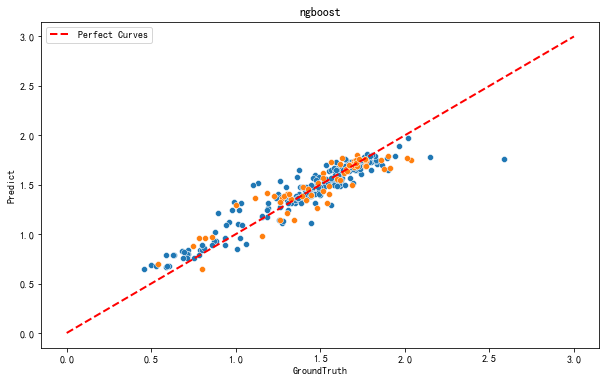


【CV-5】  R²=0.725374±0.098390 | MAE=0.112341±0.011630 | RMSE=0.175696±0.032320


In [3]:
ngb = NGBRegressor(
    Dist=Normal,       
    Score=CRPS,        
    n_estimators=200,
    learning_rate=0.2,
    verbose=False
)


model = Model(ngb, X_train, X_test, y_train, y_test, 'nGBoost', 'air_3')

visual(model, 'ngboost', X_train, X_test, y_train, y_test)

kf = KFold(n_splits=5, shuffle=True, random_state=43)

scoring = {
    'r2': make_scorer(r2_score),
    'mae': make_scorer(mean_absolute_error),
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

cv_results = cross_validate(
    ngb, X_train, y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=False
)

r2_mean,  r2_std  = cv_results['test_r2'].mean(),  cv_results['test_r2'].std(ddof=1)
mae_mean, mae_std = cv_results['test_mae'].mean(), cv_results['test_mae'].std(ddof=1)
rmse_mean,rmse_std= cv_results['test_rmse'].mean(),cv_results['test_rmse'].std(ddof=1)

print(f"\n【CV-{kf.get_n_splits()}】  "
      f"R²={r2_mean:.6f}±{r2_std:.6f} | "
      f"MAE={mae_mean:.6f}±{mae_std:.6f} | "
      f"RMSE={rmse_mean:.6f}±{rmse_std:.6f}")